In [38]:
import re
import pandas as pd

def process_filename(filename):
    # 去掉末尾的.dta扩展名
    if filename.endswith('.dta'):
        filename = filename[:-4]
    
    # 使用正则表达式找到数字并去掉前导零
    # 匹配模式：\b0+(\d+)\b 表示单词边界内的前导零+数字
    def remove_leading_zeros(match):
        # 获取匹配的数字部分（去掉前导零）
        number = match.group(1)
        return number
    
    # 应用正则表达式替换
    processed = re.sub(r'\b0+(\d+)\b', remove_leading_zeros, filename)
    
    return processed

In [39]:
pd.set_option('display.max_colwidth', 1000)
qualscore = pd.read_table(
    "../output/qualscore.res.20250721.txt",
    header=None,
    sep='\t',
    names=['Spectrum', 'Probability', 'Qualscore']
)
# 应用到DataFrame，生成Type列
qualscore['Spectrum'] = qualscore['Spectrum'].apply(process_filename)
pep_search_res = pd.read_table(
    "/rd1/user/lit/project/sORFs/analysis/20250707_c8_organize/results/final_pep_search_res_20250721.tsv",
    sep='\t',
    header=0,
    names=['Spectrum', 'Peptide', 'Peptide_I_L_equal','Source']
)
pep_search_res.head()

,Spectrum,Peptide,Peptide_I_L_equal,Source
0,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.90.90.3,KHEEEEAKAER,KHEEEEAKAER,msfragger_closed
1,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.91.91.3,QSSEEKEAARR,QSSEEKEAARR,msfragger_closed
2,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.92.92.3,EGSGSSGTGEQKEDQKEEK,EGSGSSGTGEQKEDQKEEK,msfragger_closed
3,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.101.101.3,YKAEDEKQR,YKAEDEKQR,msfragger_closed
4,CAD20250514licq_BSEP_DDA_60min_21pcw_1_C8_T_T_Slot2-3_1_7020.102.102.3,YKAEDEKQR,YKAEDEKQR,msfragger_closed


In [43]:
merged_df = pd.merge(qualscore, pep_search_res, on='Spectrum', how='left')
merged_df['Source'] = merged_df['Source'].fillna('Unidentified')
merged_df.head()
merged_df.Source.value_counts()

Source
msfragger_closed      55966
Unidentified          25367
msfragger_open        14672
pfind_open             9907
pfind_closed           1935
primenovo_punifind      299
Name: count, dtype: int64

In [46]:
merged_df.to_csv('../results/pep.search.qualscore.20250721.csv', index=False)

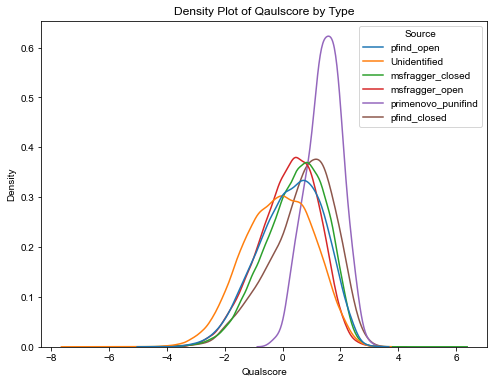

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.kdeplot(data=merged_df, x='Qualscore', hue='Source', common_norm=False)
plt.title('Density Plot of Qaulscore by Type')
plt.xlabel('Qualscore')
plt.ylabel('Density')
plt.show()